In [2]:
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
import pandas as pd
import numpy as np
from mordred import Calculator, descriptors

In [5]:
from rdkit.Chem import AllChem, Descriptors, MACCSkeys
from rdkit.Chem import rdMolDescriptors  # Import rdMolDescriptors
import numpy as np
import pandas as pd
sdf_file = "DrgBnk.sdf"
supplier = Chem.SDMolSupplier(sdf_file)
sample_molecules = [mol for mol in supplier if mol is not None][:200]
if len(sample_molecules) ==0:
    raise ValueError("No valid molecules found in the SDF file.")


descriptors = []
fingerprints_dl = []
fingerprints_maccs = []

for mol in sample_molecules:
    descriptors.append([
        Descriptors.MolLogP(mol),
        Descriptors.MolWt(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.FractionCSP3(mol),
        Descriptors.HeavyAtomCount(mol),
        Descriptors.NHOHCount(mol),
        Descriptors.NOCount(mol),
        Descriptors.RingCount(mol),
        Descriptors.MaxPartialCharge(mol),
        Descriptors.MinAbsEStateIndex(mol),
        Descriptors.FpDensityMorgan1(mol),
        Descriptors.SlogP_VSA1(mol),
        Descriptors.SlogP_VSA2(mol),
        Descriptors.NumRadicalElectrons(mol)
    ])
    fingerprints_dl.append(AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024))
    fingerprints_maccs.append(MACCSkeys.GenMACCSKeys(mol))  # Corrected line

fingerprints_array_dl = np.array([list(fp1) for fp1 in fingerprints_dl])
fingerprints_array_maccs = np.array([list(fp2) for fp2 in fingerprints_maccs])

descriptors_df = pd.DataFrame(descriptors, columns=[
    'LogP', 'MolWt', 'TPSA', 'NumHDonors', 'NumAcceptors',
    'FractionCSP3', 'HeavyAtomCount', 'NHOHCount', 'NOCount', 'RingCount', 'MaxPartialCharge',
    'MinAbsEStateIndex', 'FpDensityMorgan1', 'SlogP_VSA1', 'SlogP_VSA2', 'NumRadicalElectrons'
])
fingerprint_df_dl = pd.DataFrame(fingerprints_array_dl)
fingerprint_df_maccs = pd.DataFrame(fingerprints_array_maccs)

print("Descriptors DataFrame:")
print(descriptors_df)
print("\nFingerprints_dl DataFrame:")
print(fingerprint_df_dl)
print("\nFingerprints_maccs DataFrame:")
print(fingerprint_df_maccs)

descriptors_df.to_csv("D:/DOWNLOAD_SECTION/descriptors_nw.csv", index=False)
fingerprint_df_dl.to_csv("D:/DOWNLOAD_SECTION/fingerprints_dl_nw.csv", index=False)
fingerprint_df_maccs.to_csv("D:/DOWNLOAD_SECTION/fingerprints_maccs_nw.csv", index=False)

[15:43:26] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 36 ignored
[15:43:26] Explicit valence for atom # 13 Cl, 5, is greater than permitted
[15:43:26] ERROR: Could not sanitize molecule ending on line 126776
[15:43:26] ERROR: Explicit valence for atom # 13 Cl, 5, is greater than permitted
[15:43:26] Explicit valence for atom # 19 O, 2, is greater than permitted
[15:43:26] ERROR: Could not sanitize molecule ending on line 171722
[15:43:26] ERROR: Explicit valence for atom # 19 O, 2, is greater than permitted
[15:43:26] The bonds on one end of an atropisomer are both UP or both DOWN - atoms are: 4 5
[15:43:26] Explicit valence for atom # 15 O, 3, is greater than permitted
[15:43:26] ERROR: Could not sanitize molecule ending on line 260017
[15:43:26] ERROR: Explicit valence for atom # 15 O, 3, is greater than permitted
[15:43:27] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 16 ignored
[15:43:27] Warning: ambiguous stereochemistry - opp

Descriptors DataFrame:
        LogP     MolWt    TPSA  NumHDonors  NumAcceptors  FractionCSP3  \
0   -8.11643  2180.317  901.57          28            29      0.540816   
1   -3.10570  1269.433  495.89          17            16      0.508475   
2    4.86760  1811.253  519.89          20            16      0.510417   
3   -4.13203  1069.238  435.41          14            15      0.478261   
4   -0.50613  1431.064  495.67          17            16      0.428571   
..       ...       ...     ...         ...           ...           ...   
195  4.86970   310.481   20.23           1             1      0.727273   
196 -1.65120   334.332  146.89           3             8      0.533333   
197  0.96100   224.260   75.27           2             3      0.545455   
198  6.10372   348.486   37.30           1             1      0.375000   
199  4.16400   384.586   69.64           2             4      0.700000   

     HeavyAtomCount  NHOHCount  NOCount  RingCount  MaxPartialCharge  \
0               

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors

# Assuming descriptors_df, fingerprint_df_dl, fingerprint_df_maccs, and molecules are already defined
x = pd.concat([descriptors_df, fingerprint_df_dl, fingerprint_df_maccs], axis=1)
y = [Descriptors.MolWt(mol) for mol in sample_molecules]

# Clean your data
# Replace inf and -inf with NaN
x.replace([np.inf, -np.inf], np.nan, inplace=True)
# Drop rows with NaN values
x.dropna(inplace=True)

# Ensure x and y have the same length
x = x.iloc[:len(y)]  # Truncate x to the length of y if y is shorter
y = y[:len(x)]  # Adjust y to match x length after cleaning

# Re-split the data after cleaning
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.columns = x_train.columns.astype(str)
x_test.columns = x_test.columns.astype(str)

# Define models
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoosting": AdaBoostRegressor(random_state=42)
}

results = {}
for model_name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[model_name] = {"MAE": mae, "R^2": r2}
    print(f"\n{model_name} Results:")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"R^2 Score: {r2}")


Random Forest Results:
Mean Absolute Error (MAE): 149.93061675000013
R^2 Score: -0.11842769728261082

Gradient Boosting Results:
Mean Absolute Error (MAE): 176.8385599803365
R^2 Score: -0.4597372571734446

AdaBoosting Results:
Mean Absolute Error (MAE): 167.52548312540634
R^2 Score: -0.5120019266439308


In [11]:
from sklearn.base import BaseEstimator, RegressorMixin

class EnsembleModel(BaseEstimator, RegressorMixin):
    def __init__(self, models):
        self.models = models

    def fit(self, x, y):
        for model in self.models.values():
            model.fit(x, y)
        return self

    def predict(self, x):
        predictions = np.array([model.predict(x) for model in self.models.values()])
        return np.mean(predictions, axis=0)

# Assuming x_train, x_test, y_train, y_test are already defined
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoosting": AdaBoostRegressor(random_state=42)
}

results = {}
predictions = {}

for model_name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    predictions[model_name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[model_name] = {"MAE": mae, "R^2": r2}

    print(f"\n{model_name} Results:")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"R^2 Score: {r2}")

# Create and fit the ensemble model
ensemble_model = EnsembleModel(models)
ensemble_model.fit(x_train, y_train)
ensemble_predictions = ensemble_model.predict(x_test)

# Evaluate the ensemble model
ensemble_mae = mean_absolute_error(y_test, ensemble_predictions)
ensemble_r2 = r2_score(y_test, ensemble_predictions)

print(f"\nEnsemble Model Results:")
print(f"Mean Absolute Error (MAE): {ensemble_mae}")
print(f"R^2 Score: {ensemble_r2}")



Random Forest Results:
Mean Absolute Error (MAE): 149.93061675000013
R^2 Score: -0.11842769728261082

Gradient Boosting Results:
Mean Absolute Error (MAE): 176.8385599803365
R^2 Score: -0.4597372571734446

AdaBoosting Results:
Mean Absolute Error (MAE): 167.52548312540634
R^2 Score: -0.5120019266439308

Ensemble Model Results:
Mean Absolute Error (MAE): 160.57031959959403
R^2 Score: -0.26689289872380284


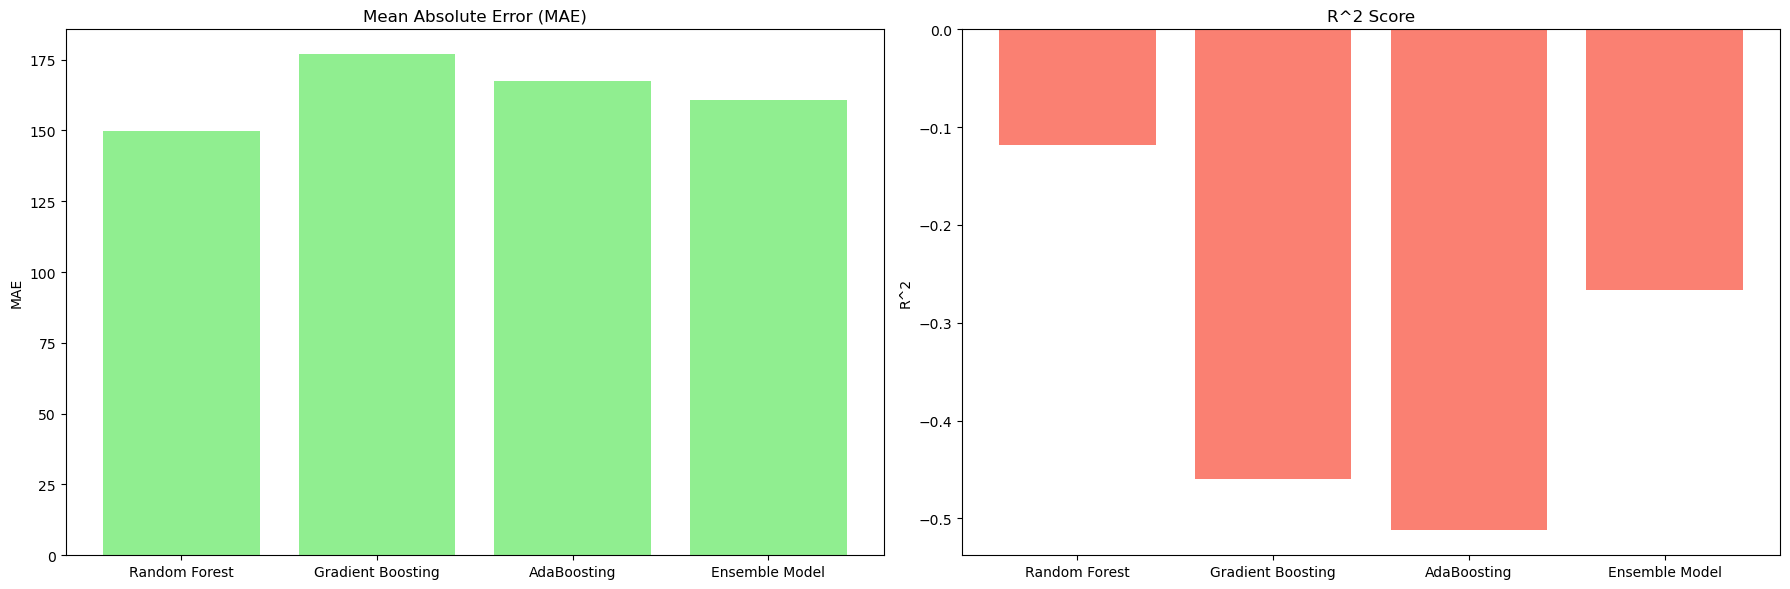

Figure saved at: C:\Users\DELL\Desktop\Chemo_project\metrics_comparison.png


In [14]:
import matplotlib.pyplot as plt

# Add ensemble model results to the existing results dictionary
results["Ensemble Model"] = {"MAE": ensemble_mae, "R^2": ensemble_r2}

metrics = ["MAE", "R^2"]
models_list = list(results.keys())

metrics_values = {metric: [results[model][metric] for model in models_list] for metric in metrics}
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

ax[0].bar(models_list, metrics_values["MAE"], color="lightgreen")
ax[0].set_title("Mean Absolute Error (MAE)")
ax[0].set_ylabel("MAE")

ax[1].bar(models_list, metrics_values["R^2"], color="salmon")
ax[1].set_title("R^2 Score")
ax[1].set_ylabel("R^2")

plt.tight_layout()

# Save the figure as a PNG file before showing it
save_path = "C:\\Users\\DELL\\Desktop\\Chemo_project\\metrics_comparison.png"
plt.savefig(save_path, format='png')

plt.show()

print(f"Figure saved at: {save_path}")


C:\Users\DELL\AppData\Local\Temp\ipykernel_18640\370971261.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  viridis = cm.get_cmap("viridis", len(models_list))


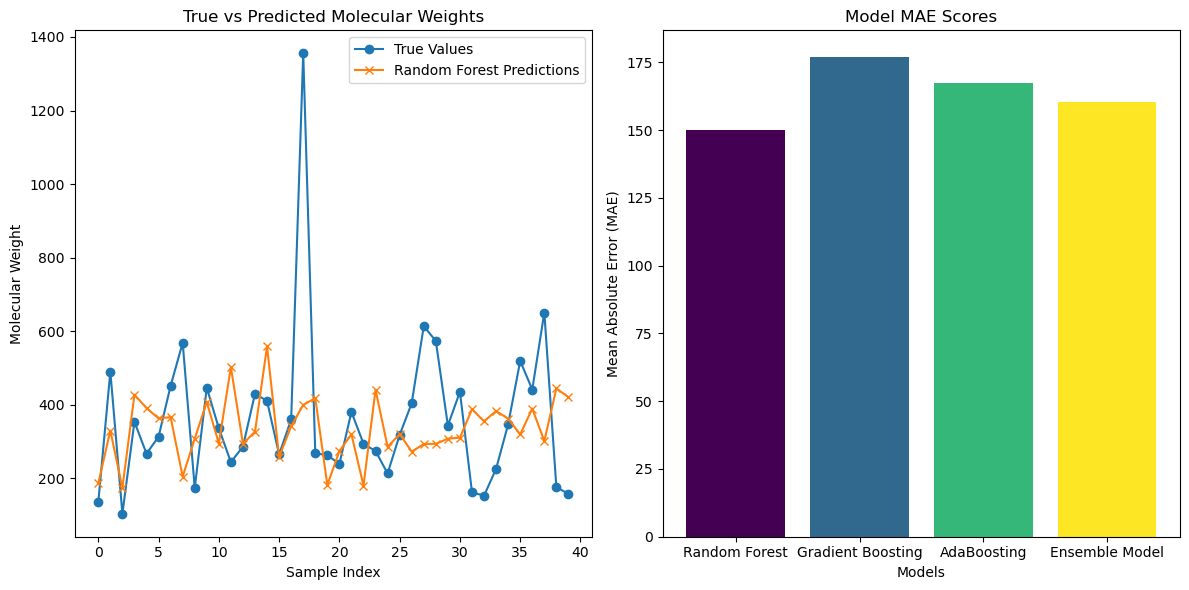

Figure saved at: C:\Users\DELL\Desktop\Chemo_project\random_forest_mae_new_metrics_comparison.png


In [23]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Add ensemble model results to the existing results dictionary
results["Ensemble Model"] = {"MAE": ensemble_mae, "R^2": ensemble_r2}

# Metrics and models list
metrics = ["MAE", "R^2"]
models_list = list(results.keys())

# Metrics values
metrics_values = {metric: [results[model][metric] for model in models_list] for metric in metrics}

# Plot true vs. predicted molecular weights
plt.figure(figsize=(12, 6))

# Get predictions from the Random Forest model
random_forest_predictions = predictions["Random Forest"]

plt.subplot(1, 2, 1)
plt.plot(y_test, "o-", label="True Values")
plt.plot(random_forest_predictions, "x-", label="Random Forest Predictions")
plt.title("True vs Predicted Molecular Weights")
plt.xlabel("Sample Index")
plt.ylabel("Molecular Weight")
plt.legend()

# Plot model MAE scores
plt.subplot(1, 2, 2)
MAE_SCORE = [results[model]["MAE"] for model in models_list]
viridis = cm.get_cmap("viridis", len(models_list))
colors = viridis(range(len(models_list)))
plt.bar(models_list, MAE_SCORE, color=colors)
plt.title("Model MAE Scores")
plt.xlabel("Models")
plt.ylabel("Mean Absolute Error (MAE)")
plt.ylim(0, max(MAE_SCORE) + 10)
plt.tight_layout()

# Save the figure as a PNG file before showing it
save_path = "C:\\Users\\DELL\\Desktop\\Chemo_project\\random_forest_mae_new_metrics_comparison.png"
plt.savefig(save_path, format='png')

plt.show()

print(f"Figure saved at: {save_path}")



Ensemble Model Results:
Mean Absolute Error (MAE): 160.57031959959403
R^2 Score: -0.26689289872380284


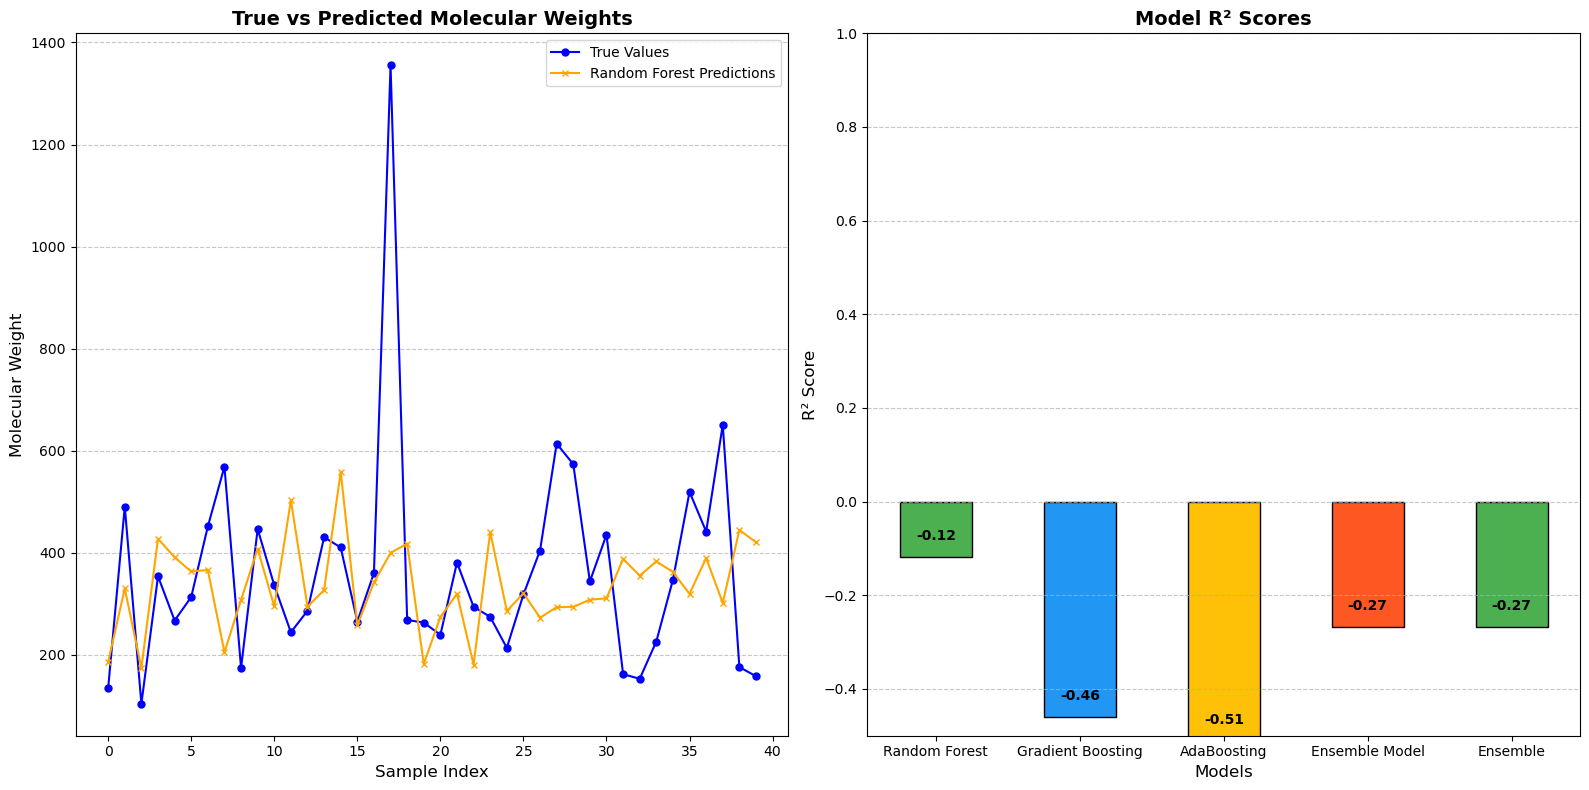

Figure saved at: C:\Users\DELL\Desktop\Chemo_project\random_forest_r2_metrics_new_comparison.png


In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# Assuming y_test, ensemble_predictions, and results are already defined
mae = mean_absolute_error(y_test, ensemble_predictions)
r2 = r2_score(y_test, ensemble_predictions)

print(f"\nEnsemble Model Results:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R^2 Score: {r2}")

# Define model names and R² scores
models_list = list(results.keys()) + ["Ensemble"]
R2_SCORE = [results[model]["R^2"] for model in results.keys()] + [r2]
colors = ["#4CAF50", "#2196F3", "#FFC107", "#FF5722"]  # Vibrant colors

# Plot figure
plt.figure(figsize=(16, 8))

# Subplot 1: True vs Predicted Molecular Weights
plt.subplot(1, 2, 1)
plt.plot(y_test, "o-", label="True Values", color='blue', markersize=5)

# Get predictions from the Random Forest model
random_forest_predictions = predictions["Random Forest"]
plt.plot(random_forest_predictions, "x-", label="Random Forest Predictions", color='orange', markersize=5)

plt.title("True vs Predicted Molecular Weights", fontsize=14, fontweight='bold')
plt.xlabel("Sample Index", fontsize=12)
plt.ylabel("Molecular Weight", fontsize=12)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Model R² Scores
plt.subplot(1, 2, 2)
bars = plt.bar(models_list, R2_SCORE, color=colors[:len(models_list)], edgecolor='black', width=0.5)

# Add R² values above bars
for bar, score in zip(bars, R2_SCORE):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,  # Adjust position
             f"{score:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# Customize appearance
plt.title("Model R² Scores", fontsize=14, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.ylim(-0.5, 1)  # Adjust the y-axis range for clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Final adjustments
plt.tight_layout()
save_path = "C:\\Users\\DELL\\Desktop\\Chemo_project\\random_forest_r2_metrics_new_comparison.png"
plt.savefig(save_path, format='png')

plt.show()

print(f"Figure saved at: {save_path}")


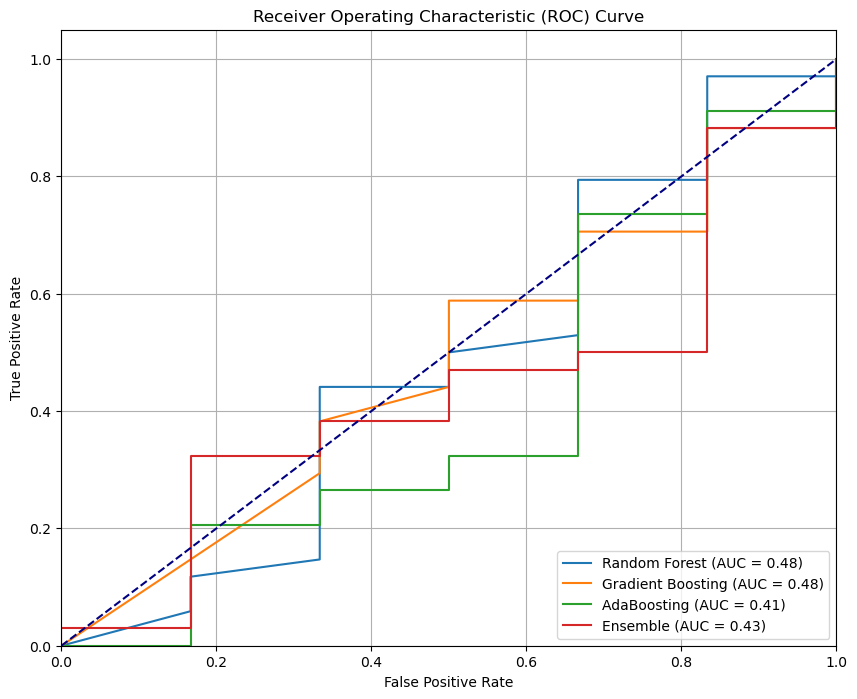

Figure saved at: C:\Users\DELL\Desktop\Chemo_project\ROC_metrics_comparison.png


In [30]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors

# Assuming descriptors_df, fingerprint_df_dl, fingerprint_df_maccs, and sample_molecules are already defined
x = pd.concat([descriptors_df, fingerprint_df_dl, fingerprint_df_maccs], axis=1)
y = [1 if Descriptors.MolWt(mol) < 500 else 0 for mol in sample_molecules]  # Binary target based on molecular weight

# Clean your data
# Replace inf and -inf with NaN
x.replace([np.inf, -np.inf], np.nan, inplace=True)
# Drop rows with NaN values
x.dropna(inplace=True)

# Ensure x and y have the same length
x = x.iloc[:len(y)]  # Truncate x to the length of y if y is shorter
y = y[:len(x)]  # Adjust y to match x length after cleaning

# Re-split the data after cleaning
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.columns = x_train.columns.astype(str)
x_test.columns = x_test.columns.astype(str)

# Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoosting": AdaBoostClassifier(random_state=42)
}

# Create the ensemble classifier
ensemble = VotingClassifier(estimators=list(models.items()), voting='soft')
models["Ensemble"] = ensemble

# Create subplots for ROC curves
plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    model.fit(x_train, y_train)
    y_pred_proba = model.predict_proba(x_test)[:, 1]  # Probabilities for the positive class

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Plot the ROC curve
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()

save_path = "C:\\Users\\DELL\\Desktop\\Chemo_project\\ROC_metrics_comparison.png"
plt.savefig(save_path, format='png')

plt.show()

print(f"Figure saved at: {save_path}")


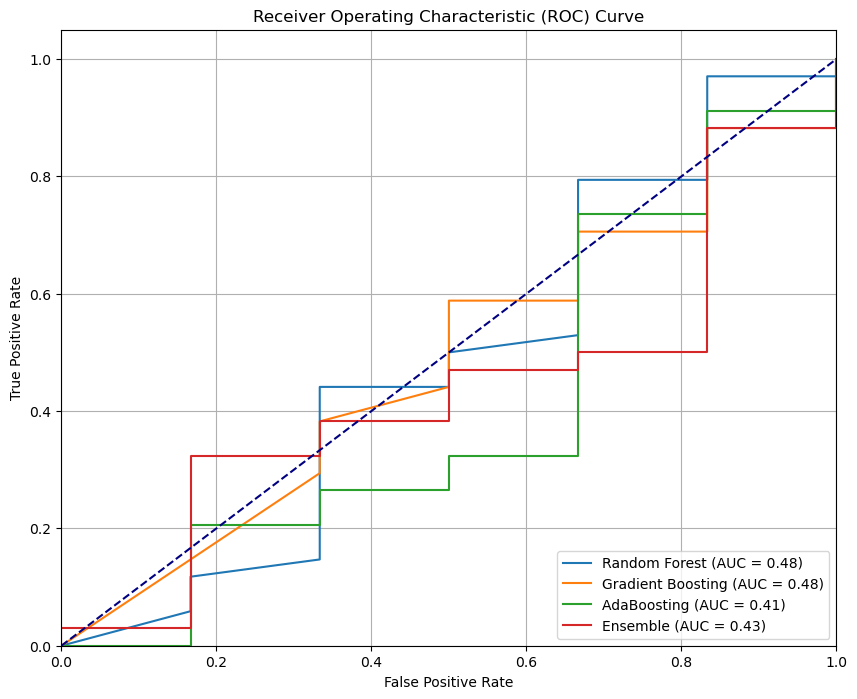

Figure saved at: C:\Users\DELL\Desktop\Chemo_project\AUC_ROC_metrics_comparison.png

AUC Scores:
Random Forest: 0.48
Gradient Boosting: 0.48
AdaBoosting: 0.41
Ensemble: 0.43


In [33]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors

# Assuming descriptors_df, fingerprint_df_dl, fingerprint_df_maccs, and sample_molecules are already defined
x = pd.concat([descriptors_df, fingerprint_df_dl, fingerprint_df_maccs], axis=1)
y = [1 if Descriptors.MolWt(mol) < 500 else 0 for mol in sample_molecules]  # Binary target based on molecular weight

# Clean your data
# Replace inf and -inf with NaN
x.replace([np.inf, -np.inf], np.nan, inplace=True)
# Drop rows with NaN values
x.dropna(inplace=True)

# Ensure x and y have the same length
x = x.iloc[:len(y)]  # Truncate x to the length of y if y is shorter
y = y[:len(x)]  # Adjust y to match x length after cleaning

# Re-split the data after cleaning
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.columns = x_train.columns.astype(str)
x_test.columns = x_test.columns.astype(str)

# Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoosting": AdaBoostClassifier(random_state=42)
}

# Create the ensemble classifier
ensemble = VotingClassifier(estimators=list(models.items()), voting='soft')
models["Ensemble"] = ensemble

# Create subplots for ROC curves
plt.figure(figsize=(10, 8))

# Calculate AUC scores for each model and plot ROC curves
auc_scores = {}
for model_name, model in models.items():
    model.fit(x_train, y_train)
    y_pred_proba = model.predict_proba(x_test)[:, 1]  # Probabilities for the positive class

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    auc_scores[model_name] = roc_auc
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Plot the ROC curve
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
save_path = "C:\\Users\\DELL\\Desktop\\Chemo_project\\AUC_ROC_metrics_comparison.png"
plt.savefig(save_path, format='png')

plt.show()

print(f"Figure saved at: {save_path}")

# Print AUC scores for each model
print("\nAUC Scores:")
for model_name, score in auc_scores.items():
    print(f"{model_name}: {score:.2f}")


In [36]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, MACCSkeys
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV

# Define the SMILES strings for each compound
smiles_dict = {
    "Aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O",
    "Ibuprofen": "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
    "Naproxen": "C[C@@H](C1=CC2=C(C=C1)C=C(C=C2)OC)C(=O)O",
    "Celecoxib": "CC1=CC=C(C=C1)C2=CC(=NN2C3=CC=C(C=C3)S(=O)(=O)N)C(F)(F)F"
}

# Function to calculate descriptors and fingerprints
def calculate_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"Invalid SMILES: {smiles}")
        return None
    descriptors = [
        Descriptors.MolLogP(mol),
        Descriptors.MolWt(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.FractionCSP3(mol),
        Descriptors.HeavyAtomCount(mol),
        Descriptors.NHOHCount(mol),
        Descriptors.NOCount(mol),
        Descriptors.RingCount(mol),
        Descriptors.MaxPartialCharge(mol),
        Descriptors.MinAbsEStateIndex(mol),
        Descriptors.FpDensityMorgan1(mol),
        Descriptors.SlogP_VSA1(mol),
        Descriptors.SlogP_VSA2(mol),
        Descriptors.NumRadicalElectrons(mol),
        Descriptors.BalabanJ(mol),
        Descriptors.HallKierAlpha(mol)
    ]
    fingerprint_dl = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
    fingerprint_maccs = MACCSkeys.GenMACCSKeys(mol)
    return descriptors, fingerprint_dl, fingerprint_maccs

# Prepare feature columns
descriptor_columns = [
    'LogP', 'MolWt', 'TPSA', 'NumHDonors', 'NumAcceptors',
    'FractionCSP3', 'HeavyAtomCount', 'NHOHCount', 'NOCount', 'RingCount',
    'MaxPartialCharge', 'MinAbsEStateIndex', 'FpDensityMorgan1', 'SlogP_VSA1',
    'SlogP_VSA2', 'NumRadicalElectrons', 'BalabanJ', 'HallKierAlpha'
]
fingerprint_columns_dl = [f'FP_DL_{i}' for i in range(1024)]
fingerprint_columns_maccs = [f'FP_MACCS_{i}' for i in range(167)]

# Prepare data
data = []
for compound, smiles in smiles_dict.items():
    descriptors, fingerprint_dl, fingerprint_maccs = calculate_features(smiles)
    if descriptors is None:  # Skip invalid molecules
        continue
    features = descriptors + list(fingerprint_dl) + list(fingerprint_maccs)
    data.append(features)

# Combine descriptors and fingerprints into DataFrame
columns = descriptor_columns + fingerprint_columns_dl + fingerprint_columns_maccs
new_features_df = pd.DataFrame(data, columns=columns)

# Known molecular weights for training (adjust accordingly)
known_molwt = [180.16, 206.28, 230.26, 381.38]  # Actual molecular weights of Aspirin, Ibuprofen, Naproxen, Celecoxib

# Scale the features
scaler = StandardScaler()
new_features_df_scaled = scaler.fit_transform(new_features_df)

# Define the Random Forest model
rf_model = RandomForestRegressor(random_state=42)

# Define the parameter grid for Grid Search
param_grid = {
    'n_estimators': [100, 500],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Perform Grid Search with cross-validation (cv=2)
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=2, n_jobs=-1, verbose=2)
grid_search.fit(new_features_df_scaled, known_molwt)

# Print the best parameters found by Grid Search
print("Best parameters found by Grid Search:")
print(grid_search.best_params_)

# Train the Random Forest model with the best parameters
best_rf_model = grid_search.best_estimator_
best_rf_model.fit(new_features_df_scaled, known_molwt)

# Define the SMILES strings for prediction
smiles_list = [
    "CC(=O)OC1=CC=CC=C1C(=O)O",  # Aspirin
    "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",  # Ibuprofen
    "C[C@@H](C1=CC2=C(C=C1)C=C(C=C2)OC)C(=O)O",  # Naproxen
    "CC1=CC=C(C=C1)C2=CC(=NN2C3=CC=C(C=C3)S(=O)(=O)N)C(F)(F)F"  # Celecoxib
]

# Function to calculate descriptors and fingerprints for a given SMILES string
def calculate_prediction_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"Warning: Could not parse SMILES string: {smiles}")
        return None
    descriptors = [
        Descriptors.MolLogP(mol),
        Descriptors.MolWt(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.FractionCSP3(mol),
        Descriptors.HeavyAtomCount(mol),
        Descriptors.NHOHCount(mol),
        Descriptors.NOCount(mol),
        Descriptors.RingCount(mol),
        Descriptors.MaxPartialCharge(mol),
        Descriptors.MinAbsEStateIndex(mol),
        Descriptors.FpDensityMorgan1(mol),
        Descriptors.SlogP_VSA1(mol),
        Descriptors.SlogP_VSA2(mol),
        Descriptors.NumRadicalElectrons(mol),
        Descriptors.BalabanJ(mol),
        Descriptors.HallKierAlpha(mol)
    ]
    fingerprint_dl = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
    fingerprint_maccs = MACCSkeys.GenMACCSKeys(mol)
    feature_vector = descriptors + list(map(int, fingerprint_dl.ToBitString())) + list(map(int, fingerprint_maccs.ToBitString()))
    return feature_vector

# Create a list of feature vectors for each SMILES
all_features = []
for smiles in smiles_list:
    features = calculate_prediction_features(smiles)
    if features:
        all_features.append(features)

# Handle possible None values in the all_features list
all_features = [np.array(x) for x in all_features if x is not None]

# Impute missing values with the mean
imputer = SimpleImputer(strategy='mean')
all_features = imputer.fit_transform(all_features)

# Standardize the features
all_features_scaled = scaler.transform(all_features)

# Make predictions on the new SMILES strings
predicted_mw = best_rf_model.predict(all_features_scaled)

# Print the predicted Molecular Weights
for i, smiles in enumerate(smiles_list):
    print(f"SMILES: {smiles}")
    print(f"Predicted Molecular Weight: {predicted_mw[i]:.2f}")
    print("-" * 20)


[16:00:33] DEPRECATION WARNING: please use MorganGenerator
[16:00:33] DEPRECATION WARNING: please use MorganGenerator
[16:00:33] DEPRECATION WARNING: please use MorganGenerator
[16:00:33] DEPRECATION WARNING: please use MorganGenerator


Fitting 2 folds for each of 16 candidates, totalling 32 fits
Best parameters found by Grid Search:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
SMILES: CC(=O)OC1=CC=CC=C1C(=O)O
Predicted Molecular Weight: 198.62
--------------------
SMILES: CC(C)CC1=CC=C(C=C1)C(C)C(=O)O
Predicted Molecular Weight: 215.69
--------------------
SMILES: C[C@@H](C1=CC2=C(C=C1)C=C(C=C2)OC)C(=O)O
Predicted Molecular Weight: 225.23
--------------------
SMILES: CC1=CC=C(C=C1)C2=CC(=NN2C3=CC=C(C=C3)S(=O)(=O)N)C(F)(F)F
Predicted Molecular Weight: 330.65
--------------------


[16:00:41] DEPRECATION WARNING: please use MorganGenerator
[16:00:41] DEPRECATION WARNING: please use MorganGenerator
[16:00:41] DEPRECATION WARNING: please use MorganGenerator
[16:00:41] DEPRECATION WARNING: please use MorganGenerator
C:\Users\DELL\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [39]:
# Define the SMILES strings for each compound
smiles_dict = {
    "Aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O",
    "Ibuprofen": "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
    "Naproxen": "C[C@@H](C1=CC2=C(C=C1)C=C(C=C2)OC)C(=O)O",
    "Celecoxib": "CC1=CC=C(C=C1)C2=CC(=NN2C3=CC=C(C=C3)S(=O)(=O)N)C(F)(F)F"
}

# Lipinski's Rule of Five
def lipinski_rule_of_five(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {"Error": "Invalid SMILES"}

    # Calculate properties
    mol_weight = Descriptors.MolWt(mol) * 1e-3
    num_h_donors = Descriptors.NumHDonors(mol)
    num_h_acceptors = Descriptors.NumHAcceptors(mol)
    log_p = Descriptors.MolLogP(mol)

    # Evaluate Lipinski's Rule of Five
    rule_of_five = {
        "Molecular Weight < 0.5": mol_weight < 0.5,
        "Hydrogen Bond Donors <= 5": num_h_donors <= 5,
        "Hydrogen Bond Acceptors <= 10": num_h_acceptors <= 10,
        "Log P <= 5": log_p <= 5,
    }

    is_valid = all(rule_of_five.values())

    return {
        "Molecular Weight": mol_weight,
        "Hydrogen Bond Donors": num_h_donors,
        "Hydrogen Bond Acceptors": num_h_acceptors,
        "Log P": log_p,
        "Rule of Five": rule_of_five,
        "Is Valid": is_valid
    }

# Evaluate compounds
results = {compound: lipinski_rule_of_five(smiles) for compound, smiles in smiles_dict.items()}

# Print results and select valid molecules
valid_molecules = {}
for compound, result in results.items():
    print(f"\n{compound} Results:")
    for key, value in result.items():
        if isinstance(value, dict):
            print(f"  {key}:")
            for sub_key, sub_value in value.items():
                print(f"    {sub_key}: {sub_value}")
        else:
            print(f"  {key}: {value}")

    if result["Is Valid"]:
        valid_molecules[compound] = result

print("\nValid Molecules for Docking:")
for compound in valid_molecules.keys():
    print(f"  {compound}")



Aspirin Results:
  Molecular Weight: 0.18015899999999996
  Hydrogen Bond Donors: 1
  Hydrogen Bond Acceptors: 3
  Log P: 1.3101
  Rule of Five:
    Molecular Weight < 0.5: True
    Hydrogen Bond Donors <= 5: True
    Hydrogen Bond Acceptors <= 10: True
    Log P <= 5: True
  Is Valid: True

Ibuprofen Results:
  Molecular Weight: 0.20628499999999997
  Hydrogen Bond Donors: 1
  Hydrogen Bond Acceptors: 1
  Log P: 3.073200000000001
  Rule of Five:
    Molecular Weight < 0.5: True
    Hydrogen Bond Donors <= 5: True
    Hydrogen Bond Acceptors <= 10: True
    Log P <= 5: True
  Is Valid: True

Naproxen Results:
  Molecular Weight: 0.230263
  Hydrogen Bond Donors: 1
  Hydrogen Bond Acceptors: 2
  Log P: 3.036500000000001
  Rule of Five:
    Molecular Weight < 0.5: True
    Hydrogen Bond Donors <= 5: True
    Hydrogen Bond Acceptors <= 10: True
    Log P <= 5: True
  Is Valid: True

Celecoxib Results:
  Molecular Weight: 0.3813790000000001
  Hydrogen Bond Donors: 1
  Hydrogen Bond Acceptors